In [15]:
import tensorflow as tf
import csv
# import PIL
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
import os
from absl import app
from absl import flags
from absl import logging
import datetime
# import cv2

FLAGS = flags.FLAGS

IMAGE_SIZE = (324, 244)
INV_IMAGE_SIZE = (244, 324)
BATCH_SIZE = 8
EPOCHS = 50

Create model

In [42]:
# Define the model
# model = Sequential([
#     Conv2D(32, (3, 3), activation='relu', input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 1)),
#     MaxPooling2D((2, 2)),
#     Conv2D(64, (3, 3), activation='relu'),
#     MaxPooling2D((2, 2)),
#     # Conv2D(128, (3, 3), activation='relu'),
#     # MaxPooling2D((2, 2)),
#     Flatten(),
#     Dense(128, activation='relu'),
#     Dropout(0.5),
#     Dense(1, activation='linear')  # Output layer for on/off, distance, x-pixel, y-pixel
# ])
# # Alternative model
model = tf.keras.models.Sequential([
  tf.keras.layers.Flatten(input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 1)),
  tf.keras.layers.Dense(16, activation='relu'),
  # tf.keras.layers.Dense(32, activation='relu'),
  tf.keras.layers.Dropout(0.2),
  tf.keras.layers.Dense(2)
])


# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)

model.summary()

/home/saab/examensarbete/AI-deck/image_processing/my_virtual_env/lib/python3.10/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 79056)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │     1,264,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │            34 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,264,946 (4.83 MB)

 Trainable params: 1,264,946 (4.83 MB)

 Non-trainable params: 0 (0.00 B)

Load data and train the model

In [43]:
# Define constants
# DISTANCE = 0.5
# IMAGE_FOLDER = f'data_collection/train/on/{DISTANCE}m/'
# LABEL_FILE = 'data_collection/train/0.6m/data.csv'

# Function to load images
def load_images(image_list, image_folder, num_images):
    for i in range(1, num_images+1):
        image_path = os.path.join(image_folder, f'img_{i:06d}.png')
        image = load_img(image_path, color_mode='grayscale', target_size=IMAGE_SIZE)
        image = img_to_array(image) / 255.0
        image_list.append(image)
    return image_list

# Function to load labels
def load_labels(label_list, num_of_images, on_off, distance):
    for i in range(1, num_of_images+1):
        label_list.append(np.array(on_off))

    # with open(label_file, 'r') as file:
    #     for line in file:
    #         labels.append([float(line)])
            # labels.append([float(value) for value in line.strip().split(', ')])
    # print(len(np.array(labels)))
    return label_list

# Load the data

# print(num_images)  # Assuming all files are images
# dist = 0.1
# on_off = 1
# labels = []
# images = []
# while dist <= 0.6:
#     img_folder = f'data_collection/train/on/{round(dist, 1)}m/'
#     num_images = len(os.listdir(img_folder))
#     images = load_images(images, img_folder, num_images)
#     labels = load_labels(labels, num_images, on_off, dist)
#     dist += 0.1

# img_folder = f'data_collection/train/on/1.0m/'
# num_images = len(os.listdir(img_folder))
# images = load_images(images, img_folder, num_images)
# labels = load_labels(labels, num_images, on_off, 1.0)

# img_folder = f'data_collection/train/on/1.5m/'
# num_images = len(os.listdir(img_folder))
# images = load_images(images, img_folder, num_images)
# labels = load_labels(labels, num_images, on_off, 1.5)

labels = []
images = []
img_val = []
label_val = []

on_off = [1, 0]
img_folder = f'classification/training_data/train/class_1/'
num_images = len(os.listdir(img_folder))
images = load_images(images, img_folder, num_images)
labels = load_labels(labels, num_images, on_off, 0)

img_folder = f'classification/training_data/validation/class_1/'
num_images = len(os.listdir(img_folder))
img_val = load_images(images, img_folder, num_images)
label_val = load_labels(labels, num_images, on_off, 0)

on_off = [0, 1]
img_folder = f'classification/training_data/train/class_2/'
num_images = len(os.listdir(img_folder))
images = load_images(images, img_folder, num_images)
labels = load_labels(labels, num_images, on_off, 0)

img_folder = f'classification/training_data/validation/class_2/'
num_images = len(os.listdir(img_folder))
img_val = load_images(images, img_folder, num_images)
label_val = load_labels(labels, num_images, on_off, 0)


# print(f'Num of images: {len(images)}')

labels = np.array(labels)
images = np.array(images)

label_val = np.array(label_val)
img_val = np.array(img_val)
# Split the data into training and validation sets
# x_train, x_val, y_train, y_val = train_test_split(images, labels, test_size=0.2, random_state=42)
# Train the model
history = model.fit(images, labels)
# history = model.train_on_batch(x_train, y_train)
model.evaluate(img_val, label_val)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 162.3454 - mae: 6.4794
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.5027 - mae: 0.5031 


[0.5030384659767151, 0.5031463503837585]

Run inference

array size: (244, 324)


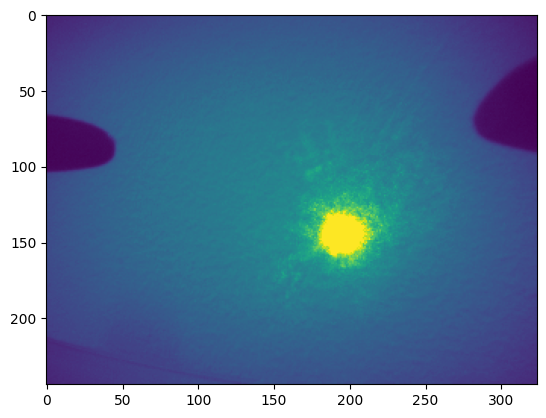

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
[0.07596905 0.0121421 ]


In [40]:
TEST_IMAGE = 'data_collection/train/on/0.1m/img_000021.png'
# TEST_IMAGE = 'data_collection/train/off/img_000612.png'

test_image = load_img(TEST_IMAGE, color_mode='grayscale', target_size=INV_IMAGE_SIZE)
test_image = img_to_array(test_image) / 255.0
print(f'array size: ({len(test_image)}, {len(test_image[0])})')
plt.imshow(test_image)
plt.show()
test_image = np.expand_dims(test_image, axis=0)
predictions = model.predict(test_image)
print(predictions[0])
# score = model.evaluate(test_image, np.array([0.6]), verbose=0)
# print(f'Test loss: {score[0]} / Test accuracy: {score[1]}')

Convert to TFLite

In [14]:
def convert_tflite_model(model):
    """Convert the save TF model to tflite model, then save it as .tflite flatbuffer format
        Args:
            model (tf.keras.Model): the trained hello_world Model
        Returns:
            The converted model in serialized format.
    """
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    tflite_model = converter.convert()
    return tflite_model

def save_tflite_model(tflite_model, save_dir, model_name):
    """save the converted tflite model
    Args:
      tflite_model (binary): the converted model in serialized format.
      save_dir (str): the save directory
      model_name (str): model name to be saved
    """
    if not os.path.exists(save_dir):
        os.makedirs(save_dir)
    save_path = os.path.join(save_dir, model_name)
    # if not os.path.exists(save_dir):
    #     os.makedirs(save_dir)
    with open(save_path, "wb+") as f:
        f.write(tflite_model)
    logging.info("Tflite model saved to %s", save_dir)

tflite_model = convert_tflite_model(model)
save_tflite_model(tflite_model, "models",model_name="classification.tflite")

INFO:tensorflow:Assets written to: /tmp/tmpduedirt7/assets


INFO:tensorflow:Assets written to: /tmp/tmpduedirt7/assets


Saved artifact at '/tmp/tmpduedirt7'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 324, 244, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  128662435864720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128662435868416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128662435869296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128662435869824: TensorSpec(shape=(), dtype=tf.resource, name=None)


W0000 00:00:1724151887.568988    5858 tf_tfl_flatbuffer_helpers.cc:392] Ignored output_format.
W0000 00:00:1724151887.569000    5858 tf_tfl_flatbuffer_helpers.cc:395] Ignored drop_control_dependency.
2024-08-20 13:04:47.569112: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpduedirt7
2024-08-20 13:04:47.569352: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2024-08-20 13:04:47.569359: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmpduedirt7
2024-08-20 13:04:47.571212: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2024-08-20 13:04:47.587283: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmpduedirt7
2024-08-20 13:04:47.591186: I tensorflow/cc/saved_model/loader.cc:462] SavedModel load for tags { serve }; Status: success: OK. Took 22076 microseconds.


Run inference

In [13]:
TEST_FOLDER = 'data_collection/train/on/0.2m'
TEST_IMAGE = 'data_collection/train/on/1.5m/img_000009.png'

# Load the TFLite model and allocate tensors.
interpreter = tf.lite.Interpreter(model_path="models/dist_est.tflite")
interpreter.allocate_tensors()

# Get input and output tensors.
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()
print(output_details)

num_test_images = len(os.listdir(TEST_FOLDER)) - 1
test_images = load_images(TEST_FOLDER, num_test_images)

test_image = load_img(TEST_IMAGE, color_mode='grayscale', target_size=IMAGE_SIZE)
test_image = img_to_array(test_image) / 255.0
print(len(test_image))
test_image = np.expand_dims(test_image, axis=0)

# Test the model on random input data.
input_shape = input_details[0]['shape']
input_data = test_image
interpreter.set_tensor(input_details[0]['index'], input_data)

interpreter.invoke()

# The function `get_tensor()` returns a copy of the tensor data.
# Use `tensor()` in order to get a pointer to the tensor.
output_data = interpreter.get_tensor(output_details[0]['index'])
print(output_data[0][0])
# help(tf.lite.Interpreter)

[{'name': 'StatefulPartitionedCall_1:0', 'index': 8, 'shape': array([1, 2], dtype=int32), 'shape_signature': array([-1,  2], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]


TypeError: load_images() missing 1 required positional argument: 'num_images'